In [2]:
import pandas as pd
from pathlib import Path
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
import random
import numpy as np

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Random seed set to {seed}")


set_seed(42)  



image_folder = Path(r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\classification_level1\AND_result_fold2")
label_path  = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\scientificProject\data\labels.csv"
label_df = pd.read_csv(label_path)
label_df["name"] = label_df["name"].astype(str)
label = {}
for item in range(len(label_df['name'])):
    label[int(label_df['name'][item].split('.')[0])] = label_df['grade'][item]
    
new_label = {}
for key, value in label.items():
    if key < 359:
        if value == 0:
            new_label[key] = value
    else:
        new_label[key] = value
        

✅ Random seed set to 42


In [3]:

image_dir = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\train_together\images"
image_paths = []
labels = []

for img_id, lbl in new_label.items():
    filename = f"{img_id}.jpg"
    full_path = os.path.join(image_dir, filename)
    if os.path.exists(full_path):
        image_paths.append(full_path)
        labels.append(lbl)
    else:
        print(f"Warning: {full_path} not found!")

image_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    # اگر لازم داری نرمال سازی رنگ‌ها رو اضافه کن
])

mask_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float())  # همین خط رو اضافه کن
])

# تعریف کلاس Dataset
class CorneaDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, mask_dir, label_dict, transform=None, mask_transform=None):
        """
        image_dir: مسیر تصاویر RGB (jpg/png)
        mask_dir: مسیر ماسک‌ها (png)
        label_dict: دیکشنری {image_id: class_label}
        transform: تبدیل‌های تصاویر (Resize, ToTensor و ...)
        mask_transform: تبدیل‌های ماسک (Resize, ToTensor و ...)
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.label_dict = label_dict
        self.transform = transform
        self.mask_transform = mask_transform
        
        self.image_names = sorted([f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))])
        
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_id = int(os.path.splitext(img_name)[0])
        
        # بارگذاری تصویر
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        
        # بارگذاری ماسک
        mask_name = os.path.splitext(img_name)[0] + '.png'  # فرض شده ماسک با همون id ولی پسوند png
        mask_path = os.path.join(self.mask_dir, mask_name)
        mask = Image.open(mask_path).convert("L")  # ماسک سیاه سفید
        
        # اعمال تبدیل‌ها
        if self.transform:
            image = self.transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)
        
        # گرفتن label کلاس
        label = self.label_dict.get(img_id, 0)  # اگر نبود 0 فرض کن
        
        return image, label, mask
    
image_dir = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\train_together\images"
mask_dir = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\train_together\ulcer_images"
# ساخت Dataset کامل
full_dataset = CorneaDataset(image_dir, mask_dir, new_label, image_transforms, mask_transforms)

# تعریف Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_indices = list(kf.split(image_paths, labels))

# مثلاً دسترسی به fold اول:
train_idx, val_idx = fold_indices[0]



train_dataset = CorneaDataset(image_dir=image_dir,
                             mask_dir=mask_dir,
                             label_dict=new_label,  # دیکشنری label که قبلا ساختی
                             transform=image_transforms,
                             mask_transform=mask_transforms)

val_dataset = Subset(full_dataset, val_idx)

# ساخت DataLoader ها

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 390, Val samples: 78


In [4]:

# تعریف Attention Gate
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        # g: از upsampling، x: از downsampling (skip connection)
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi  # وزن دهی به x با نقشه توجه

# تعریف Double Convolution Block
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

# تعریف Attention U-Net کامل
class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(AttentionUNet, self).__init__()
        # Downsampling
        self.dconv_down1 = DoubleConv(in_channels, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        
        self.maxpool = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        
        # Upsampling
        self.up_trans_4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att4 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.up_conv_4 = DoubleConv(1024, 512)
        
        self.up_trans_3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att3 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.up_conv_3 = DoubleConv(512, 256)
        
        self.up_trans_2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.up_conv_2 = DoubleConv(256, 128)
        
        self.up_trans_1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att1 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.up_conv_1 = DoubleConv(128, 64)
        
        # لایه نهایی segmentation
        self.out = nn.Conv2d(64, out_channels, kernel_size=1)
    
    def forward(self, x):
        # Downsampling path
        x1 = self.dconv_down1(x)
        x2 = self.dconv_down2(self.maxpool(x1))
        x3 = self.dconv_down3(self.maxpool(x2))
        x4 = self.dconv_down4(self.maxpool(x3))
        
        # Bottleneck
        x5 = self.bottleneck(self.maxpool(x4))
        
        # Upsampling + Attention + Padding + Concat + DoubleConv
        
        d4 = self.up_trans_4(x5)
        x4 = self.att4(g=d4, x=x4)
        diffY = x4.size(2) - d4.size(2)
        diffX = x4.size(3) - d4.size(3)
        d4 = F.pad(d4, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        d4 = torch.cat((x4, d4), dim=1)
        d4 = self.up_conv_4(d4)
        
        d3 = self.up_trans_3(d4)
        x3 = self.att3(g=d3, x=x3)
        diffY = x3.size(2) - d3.size(2)
        diffX = x3.size(3) - d3.size(3)
        d3 = F.pad(d3, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        d3 = torch.cat((x3, d3), dim=1)
        d3 = self.up_conv_3(d3)
        
        d2 = self.up_trans_2(d3)
        x2 = self.att2(g=d2, x=x2)
        diffY = x2.size(2) - d2.size(2)
        diffX = x2.size(3) - d2.size(3)
        d2 = F.pad(d2, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        d2 = torch.cat((x2, d2), dim=1)
        d2 = self.up_conv_2(d2)
        
        d1 = self.up_trans_1(d2)
        x1 = self.att1(g=d1, x=x1)
        diffY = x1.size(2) - d1.size(2)
        diffX = x1.size(3) - d1.size(3)
        d1 = F.pad(d1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        d1 = torch.cat((x1, d1), dim=1)
        d1 = self.up_conv_1(d1)
        
        feature_map = d1
        out = self.out(d1)
        return out, feature_map


class ClassifierCNNMLP(nn.Module):
    def __init__(self, in_channels=64, num_classes=5):  
        super(ClassifierCNNMLP, self).__init__()
        # توجه کن که in_channels برابر با تعداد channel خروجی لایه یکی مونده به آخر upsampling تو U-Net است (مثلا 64)
        
        self.cnn_layers = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # کاهش سایز
        
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4))  # کاهش به 4x4
        )
        
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.cnn_layers(x)
        x = self.mlp(x)
        return x


In [5]:
def set_requires_grad(model, requires_grad):
    for param in model.parameters():
        param.requires_grad = requires_grad
        

# یک epoch آموزش (train)
def train_one_epoch(unet, classifier, device, train_loader, optimizer_unet, optimizer_classifier, criterion_seg, criterion_cls):
    unet.train()
    classifier.train()
    
    total_loss_seg = 0.0
    total_loss_cls = 0.0
    
    # لیست‌هایی برای ذخیره پیش‌بینی‌ها و لیبل‌ها (برای محاسبه معیارها)
    all_preds_cls = []
    all_labels_cls = []
    
    all_preds_seg = []
    all_labels_seg = []
    
    for batch in train_loader:
        images, labels, masks = batch
        
        images = images.to(device)
        labels = labels.to(device)
        masks = masks.to(device)
        
        # --- آموزش Classifier ---
        set_requires_grad(unet, False)
        set_requires_grad(classifier, True)
        
        optimizer_classifier.zero_grad()
        
        with torch.no_grad():
            _, feature_map = unet(images)
        
        preds_cls = classifier(feature_map)  # خروجی classifier (logits)
        loss_cls = criterion_cls(preds_cls, labels)
        loss_cls.backward()
        optimizer_classifier.step()
        
        total_loss_cls += loss_cls.item()
        
        # ذخیره نتایج classification
        all_preds_cls.append(preds_cls.detach().cpu())
        all_labels_cls.append(labels.detach().cpu())
        
        # --- آموزش U-Net ---
        set_requires_grad(unet, True)
        set_requires_grad(classifier, False)
        
        optimizer_unet.zero_grad()
        
        preds_seg, _ = unet(images)  # خروجی segmentation (logits)
        loss_seg = criterion_seg(preds_seg, masks)
        loss_seg.backward()
        optimizer_unet.step()
        
        total_loss_seg += loss_seg.item()
        
        # ذخیره نتایج segmentation (قبل از تابع فعالسازی)
        all_preds_seg.append(torch.sigmoid(preds_seg).detach().cpu())  # تبدیل logits به احتمالات
        all_labels_seg.append(masks.detach().cpu())
    
    avg_loss_seg = total_loss_seg / len(train_loader)
    avg_loss_cls = total_loss_cls / len(train_loader)
    
    # concat همه batch ها
    all_preds_cls = torch.cat(all_preds_cls)
    all_labels_cls = torch.cat(all_labels_cls)
    
    all_preds_seg = torch.cat(all_preds_seg)
    all_labels_seg = torch.cat(all_labels_seg)
    
    return avg_loss_seg, avg_loss_cls, all_preds_seg, all_labels_seg, all_preds_cls, all_labels_cls



def validate_one_epoch(unet, classifier, device, val_loader, criterion_seg, criterion_cls):
    unet.eval()
    classifier.eval()
    
    total_loss_seg = 0.0
    total_loss_cls = 0.0
    
    all_preds_cls = []
    all_labels_cls = []
    
    all_preds_seg = []
    all_labels_seg = []
    
    with torch.no_grad():
        for batch in val_loader:
            images, labels, masks = batch
            
            images = images.to(device)
            labels = labels.to(device)
            masks = masks.to(device)
            
            preds_seg, feature_map = unet(images)
            preds_cls = classifier(feature_map)
            
            loss_seg = criterion_seg(preds_seg, masks)
            loss_cls = criterion_cls(preds_cls, labels)
            
            total_loss_seg += loss_seg.item()
            total_loss_cls += loss_cls.item()
            
            # ذخیره نتایج classification
            all_preds_cls.append(preds_cls.detach().cpu())
            all_labels_cls.append(labels.detach().cpu())
            
            # ذخیره نتایج segmentation
            all_preds_seg.append(torch.sigmoid(preds_seg).detach().cpu())
            all_labels_seg.append(masks.detach().cpu())
    
    avg_loss_seg = total_loss_seg / len(val_loader)
    avg_loss_cls = total_loss_cls / len(val_loader)
    
    all_preds_cls = torch.cat(all_preds_cls)
    all_labels_cls = torch.cat(all_labels_cls)
    
    all_preds_seg = torch.cat(all_preds_seg)
    all_labels_seg = torch.cat(all_labels_seg)
    
    return avg_loss_seg, avg_loss_cls, all_preds_seg, all_labels_seg, all_preds_cls, all_labels_cls




In [6]:


# def calculate_classification_metrics(preds_cls, labels_cls):
#     preds_labels = preds_cls.argmax(dim=1).numpy()
#     true_labels = labels_cls.numpy()
# 
#     acc = accuracy_score(true_labels, preds_labels)
#     f1 = f1_score(true_labels, preds_labels, average='weighted')
#     sens = recall_score(true_labels, preds_labels, average='weighted')  # sensitivity = recall
#     spec = None  # specificity را باید دستی محاسبه کنیم اگر دوتایی باشه، اینجا میشه اضافه کرد
#     return acc, f1, sens, spec
def calculate_classification_metrics(preds_cls, labels_cls):
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
    preds_labels = preds_cls.argmax(dim=1).numpy()
    true_labels = labels_cls.numpy()

    acc = accuracy_score(true_labels, preds_labels)
    balanced_acc = balanced_accuracy_score(true_labels, preds_labels)
    f1 = f1_score(true_labels, preds_labels, average='weighted')
    sens = recall_score(true_labels, preds_labels, average='weighted')
    
    # Specificity برای چندکلاسه
    cm = confusion_matrix(true_labels, preds_labels)
    tn = []
    fp = []
    for i in range(cm.shape[0]):
        temp_cm = cm.copy()
        temp_cm[i, :] = 0
        temp_cm[:, i] = 0
        tn.append(temp_cm.sum())
        fp.append(cm[:, i].sum() - cm[i,i])
    spec = sum([tn[i]/(tn[i]+fp[i]+1e-6) for i in range(len(tn))])/len(tn)
    
    return acc, balanced_acc, f1, sens, spec


# def dice_coefficient(preds, labels, threshold=0.5):
#     preds_bin = (preds > threshold).float()
#     intersection = (preds_bin * labels).sum(dim=(1,2,3))
#     union = preds_bin.sum(dim=(1,2,3)) + labels.sum(dim=(1,2,3))
#     dice = (2*intersection + 1e-6)/(union + 1e-6)
#     return dice.mean().item()
def dice_coefficient(preds, labels, threshold=0.5):
    preds_bin = (preds > threshold).float()
    intersection = (preds_bin * labels).sum(dim=(1,2,3))
    union = preds_bin.sum(dim=(1,2,3)) + labels.sum(dim=(1,2,3))
    
    # برای نمونه‌هایی که union > 0 باشد
    dice = (2 * intersection) / (union + 1e-6)
    # برای نمونه‌هایی که union == 0 باشد، dice = 0
    dice = torch.where(union > 0, dice, torch.zeros_like(dice))
    
    return dice.mean().item()

def iou_score(preds, labels, threshold=0.5):
    preds_bin = (preds > threshold).float()
    intersection = (preds_bin * labels).sum(dim=(1,2,3))
    union = preds_bin.sum(dim=(1,2,3)) + labels.sum(dim=(1,2,3)) - intersection
    iou = (intersection + 1e-6)/(union + 1e-6)
    return iou.mean().item()

def precision_score_seg(preds, labels, threshold=0.5):
    preds_bin = (preds > threshold).float()
    tp = (preds_bin * labels).sum(dim=(1,2,3))
    fp = (preds_bin * (1-labels)).sum(dim=(1,2,3))
    precision = (tp + 1e-6)/(tp + fp + 1e-6)
    return precision.mean().item()

def recall_score_seg(preds, labels, threshold=0.5):
    preds_bin = (preds > threshold).float()
    tp = (preds_bin * labels).sum(dim=(1,2,3))
    fn = ((1-preds_bin) * labels).sum(dim=(1,2,3))
    recall = (tp + 1e-6)/(tp + fn + 1e-6)
    return recall.mean().item()

In [7]:

def train_loop(unet, classifier, device, train_loader, val_loader, optimizer_unet, optimizer_classifier,
               criterion_seg, criterion_cls, epochs, patience=50):
    
    train_losses_seg = []
    val_losses_seg = []
    train_losses_cls = []
    val_losses_cls = []
    
    best_val_metric = -1  # برای accuracy که هرچه بیشتر بهتر
    patience_counter = 0
    
    for epoch in range(1, epochs+1):
        train_loss_seg, train_loss_cls, train_preds_seg, train_labels_seg, train_preds_cls, train_labels_cls = train_one_epoch(
            unet, classifier, device, train_loader,
            optimizer_unet, optimizer_classifier,
            criterion_seg, criterion_cls)
        
        val_loss_seg, val_loss_cls, val_preds_seg, val_labels_seg, val_preds_cls, val_labels_cls = validate_one_epoch(
            unet, classifier, device, val_loader, criterion_seg, criterion_cls)
        
        # --- محاسبه متریک‌ها ---
        train_acc, train_bal_acc, train_f1, train_sens, train_spec = calculate_classification_metrics(train_preds_cls, train_labels_cls)
        val_acc, val_bal_acc, val_f1, val_sens, val_spec = calculate_classification_metrics(val_preds_cls, val_labels_cls)
        
        train_dice = dice_coefficient(train_preds_seg, train_labels_seg)
        train_iou = iou_score(train_preds_seg, train_labels_seg)
        train_prec = precision_score_seg(train_preds_seg, train_labels_seg)
        train_rec = recall_score_seg(train_preds_seg, train_labels_seg)
        
        val_dice = dice_coefficient(val_preds_seg, val_labels_seg)
        val_iou = iou_score(val_preds_seg, val_labels_seg)
        val_prec = precision_score_seg(val_preds_seg, val_labels_seg)
        val_rec = recall_score_seg(val_preds_seg, val_labels_seg)
        
        # --- چاپ نتایج ---
        print(f"\nEpoch {epoch}/{epochs}")
        print(f"Train Losses -> Seg: {train_loss_seg:.4f}, Cls: {train_loss_cls:.4f}")
        print(f"Val Losses   -> Seg: {val_loss_seg:.4f}, Cls: {val_loss_cls:.4f}")
        print(f"Train Classification -> Acc: {train_acc:.4f}, Bal Acc: {train_bal_acc:.4f}, F1: {train_f1:.4f}, Sens: {train_sens:.4f}, Spec: {train_spec:.4f}")
        print(f"Val Classification   -> Acc: {val_acc:.4f}, Bal Acc: {val_bal_acc:.4f}, F1: {val_f1:.4f}, Sens: {val_sens:.4f}, Spec: {val_spec:.4f}")
        print(f"Train Segmentation -> Dice: {train_dice:.4f}, IoU: {train_iou:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}")
        print(f"Val Segmentation   -> Dice: {val_dice:.4f}, IoU: {val_iou:.4f}, Precision: {val_prec:.4f}, Recall: {val_rec:.4f}")
        
        train_losses_seg.append(train_loss_seg)
        val_losses_seg.append(val_loss_seg)
        train_losses_cls.append(train_loss_cls)
        val_losses_cls.append(val_loss_cls)
        
        # --- Early Stopping روی Accuracy validation (تغییر اینجا) ---
        if val_acc > best_val_metric:
            best_val_metric = val_acc
            patience_counter = 0
            print(f"🎯 New best accuracy: {val_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⏹️ Early stopping at epoch {epoch}!")
                break

    # --- نمایش ۵ تصویر نمونه train و val ---
    def show_sample_images(loader, unet, classifier, device, num_samples=5, dataset_type="Train", class_names=None):
        unet.eval()
        classifier.eval()
        samples_shown = 0
        
        with torch.no_grad():
            for batch in loader:
                images, labels, masks = batch
                images = images.to(device)
                masks = masks.to(device)
                labels = labels.to(device)
                
                preds_seg, feature_map = unet(images)
                preds_seg = torch.sigmoid(preds_seg)  # تبدیل logits به probability
                preds_cls = classifier(feature_map)
                preds_cls_labels = preds_cls.argmax(dim=1)
                
                for i in range(images.size(0)):
                    if samples_shown >= num_samples:
                        return
                    
                    image = images[i].cpu()
                    mask_true = masks[i].cpu()
                    mask_pred = preds_seg[i].cpu()
                    true_label = labels[i].cpu().item()
                    pred_label = preds_cls_labels[i].cpu().item()
                    
                    # 🔥 تبدیل ماسک پیش‌بینی شده به باینری
                    mask_pred_binary = (mask_pred > 0.5).float()  # آستانه‌گذاری 0.5
                    
                    # استفاده از اسم کلاس
                    true_label_str = class_names[true_label] if class_names else str(true_label)
                    pred_label_str = class_names[pred_label] if class_names else str(pred_label)
                    
                    # اصلاح شکل‌ها
                    if image.shape[0] == 3:
                        image = image.permute(1, 2, 0)
                    if mask_true.ndim == 3 and mask_true.shape[0] == 1:
                        mask_true = mask_true.squeeze(0)
                    if mask_pred_binary.ndim == 3 and mask_pred_binary.shape[0] == 1:
                        mask_pred_binary = mask_pred_binary.squeeze(0)
                    
                    plt.figure(figsize=(12, 4))
                    
                    plt.subplot(1, 3, 1)
                    plt.imshow(image)
                    plt.title(f"Image\nTrue: {true_label_str}, Pred: {pred_label_str}")
                    plt.axis('off')
                    
                    plt.subplot(1, 3, 2)
                    plt.imshow(mask_true, cmap='gray', vmin=0, vmax=1)
                    plt.title("GT Mask")
                    plt.axis('off')
                    
                    plt.subplot(1, 3, 3)
                    plt.imshow(mask_pred_binary, cmap='gray', vmin=0, vmax=1)  # 🔥 نمایش باینری
                    plt.title("Pred Mask")
                    plt.axis('off')
                    
                    plt.suptitle(f"{dataset_type} Sample - True: {true_label_str}, Pred: {pred_label_str}", 
                               fontsize=14, fontweight='bold')
                    plt.show()
                    
                    samples_shown += 1
    
    # نمایش ۵ تصویر train و ۵ تصویر val
    # show_sample_images(train_loader, num_samples=5, dataset_type="Train")
    # show_sample_images(val_loader, num_samples=5, dataset_type="Validation")
    class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]
    # 
    show_sample_images(train_loader, unet, classifier, device, num_samples=5, dataset_type="Train", class_names=class_names)
    show_sample_images(val_loader, unet, classifier, device, num_samples=5, dataset_type="Validation", class_names=class_names)

    
    
    return train_losses_seg, val_losses_seg, train_losses_cls, val_losses_cls, val_preds_cls, val_labels_cls, train_preds_cls, train_labels_cls, val_preds_seg, val_labels_seg

In [8]:

def plot_confusion_matrix(preds_cls, labels_cls, class_names=None, dataset_type="Validation"):
    """
    preds_cls: tensor خروجی classifier (logits)
    labels_cls: tensor labels واقعی
    class_names: لیست اسم کلاس‌ها
    """
    preds_labels = preds_cls.argmax(dim=1).cpu().numpy()
    true_labels = labels_cls.cpu().numpy()
    
    cm = confusion_matrix(true_labels, preds_labels)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{dataset_type} Confusion Matrix")
    plt.show()


def plot_losses(train_losses_seg, val_losses_seg, train_losses_cls, val_losses_cls):
    epochs = range(1, len(train_losses_seg)+1)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses_seg, label='Train Seg Loss')
    plt.plot(epochs, val_losses_seg, label='Val Seg Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Segmentation Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_losses_cls, label='Train Cls Loss')
    plt.plot(epochs, val_losses_cls, label='Val Cls Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Classification Loss")
    plt.legend()

    plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = AttentionUNet(in_channels=3, out_channels=1).to(device)
classifier = ClassifierCNNMLP(in_channels=64, num_classes=5).to(device)

criterion_seg = nn.BCEWithLogitsLoss()
criterion_cls = nn.CrossEntropyLoss()

optimizer_unet = optim.Adam(unet.parameters(), lr=1e-4)
optimizer_classifier = optim.Adam(classifier.parameters(), lr=1e-4)

num_epochs = 200

train_losses_seg, val_losses_seg, train_losses_cls, val_losses_cls, val_preds_cls, val_labels_cls, train_preds_cls, train_labels_cls, val_preds_seg, val_labels_seg = train_loop(
    unet, classifier, device, train_loader, val_loader, 
    optimizer_unet, optimizer_classifier, criterion_seg, criterion_cls, num_epochs
)


class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]
plot_confusion_matrix(val_preds_cls, val_labels_cls, class_names=class_names, dataset_type="Validation")

plot_confusion_matrix(train_preds_cls, train_labels_cls, class_names=class_names, dataset_type="Train")

plot_losses(train_losses_seg, val_losses_seg, train_losses_cls, val_losses_cls)


Epoch 1/200
Train Losses -> Seg: 0.5479, Cls: 1.5304
Val Losses   -> Seg: 0.4315, Cls: 1.4558
Train Classification -> Acc: 0.2436, Bal Acc: 0.1908, F1: 0.2080, Sens: 0.2436, Spec: 0.7973
Val Classification   -> Acc: 0.2949, Bal Acc: 0.2172, F1: 0.2345, Sens: 0.2949, Spec: 0.8074
Train Segmentation -> Dice: 0.8963, IoU: 0.8448, Precision: 0.9926, Recall: 0.8510
Val Segmentation   -> Dice: 0.9915, IoU: 0.9833, Precision: 0.9907, Recall: 0.9925
🎯 New best accuracy: 0.2949

Epoch 2/200
Train Losses -> Seg: 0.4039, Cls: 1.4775
Val Losses   -> Seg: 0.3623, Cls: 1.4565
Train Classification -> Acc: 0.3282, Bal Acc: 0.2465, F1: 0.2574, Sens: 0.3282, Spec: 0.8165
Val Classification   -> Acc: 0.4103, Bal Acc: 0.2977, F1: 0.3402, Sens: 0.4103, Spec: 0.8378
Train Segmentation -> Dice: 0.9886, IoU: 0.9778, Precision: 0.9820, Recall: 0.9957
Val Segmentation   -> Dice: 0.9915, IoU: 0.9834, Precision: 0.9872, Recall: 0.9960
🎯 New best accuracy: 0.4103

Epoch 3/200
Train Losses -> Seg: 0.3679, Cls: 1.4


Epoch 1/200
Train Losses -> Seg: 0.5479, Cls: 1.5304
Val Losses   -> Seg: 0.4315, Cls: 1.4558
Train Classification -> Acc: 0.2436, Bal Acc: 0.1908, F1: 0.2080, Sens: 0.2436, Spec: 0.7973
Val Classification   -> Acc: 0.2949, Bal Acc: 0.2172, F1: 0.2345, Sens: 0.2949, Spec: 0.8074
Train Segmentation -> Dice: 0.8963, IoU: 0.8448, Precision: 0.9926, Recall: 0.8510
Val Segmentation   -> Dice: 0.9915, IoU: 0.9833, Precision: 0.9907, Recall: 0.9925
🎯 New best accuracy: 0.2949

Epoch 2/200
Train Losses -> Seg: 0.4039, Cls: 1.4775
Val Losses   -> Seg: 0.3623, Cls: 1.4565
Train Classification -> Acc: 0.3282, Bal Acc: 0.2465, F1: 0.2574, Sens: 0.3282, Spec: 0.8165
Val Classification   -> Acc: 0.4103, Bal Acc: 0.2977, F1: 0.3402, Sens: 0.4103, Spec: 0.8378
Train Segmentation -> Dice: 0.9886, IoU: 0.9778, Precision: 0.9820, Recall: 0.9957
Val Segmentation   -> Dice: 0.9915, IoU: 0.9834, Precision: 0.9872, Recall: 0.9960
🎯 New best accuracy: 0.4103

Epoch 3/200
Train Losses -> Seg: 0.3679, Cls: 1.4

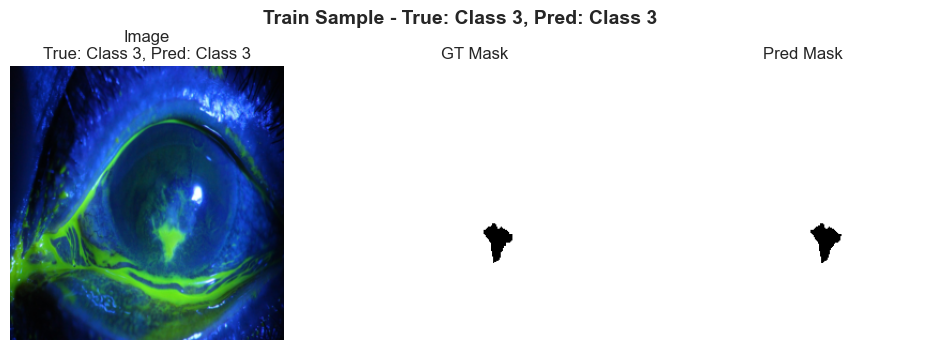

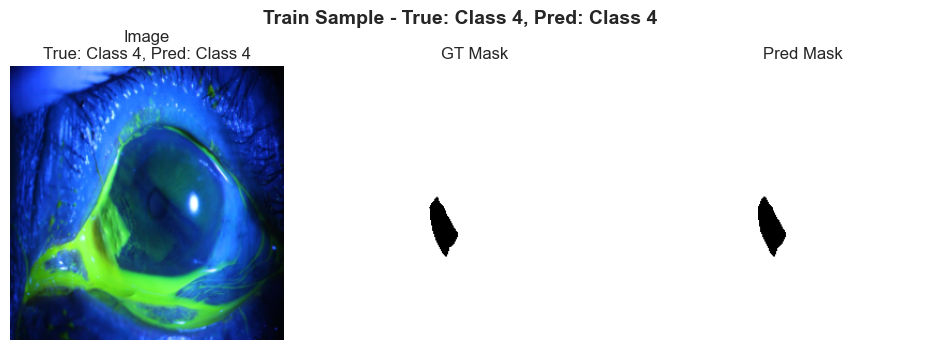

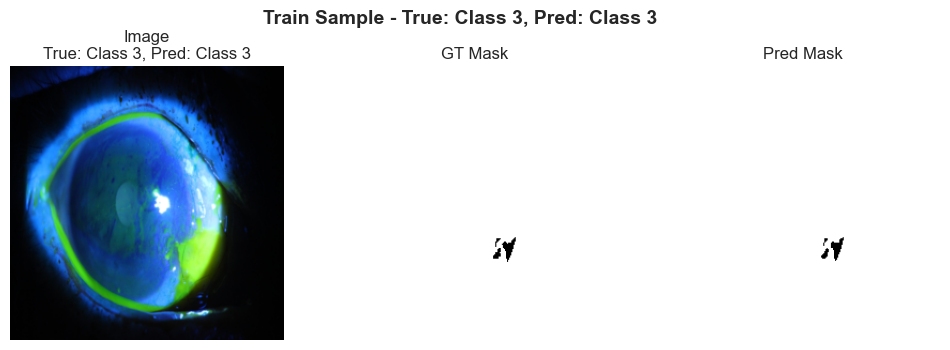

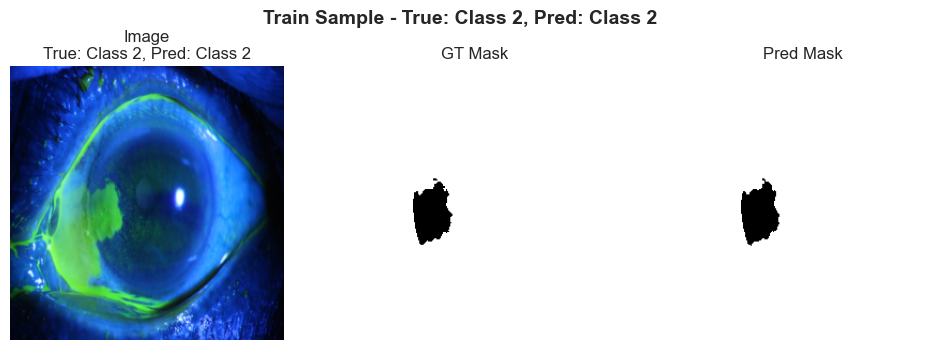

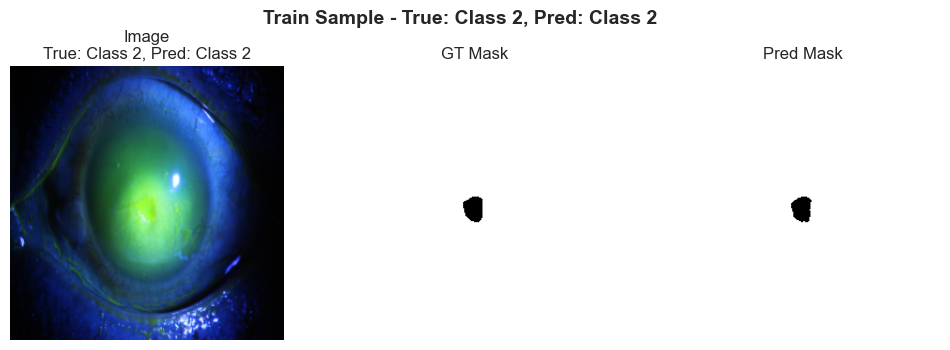

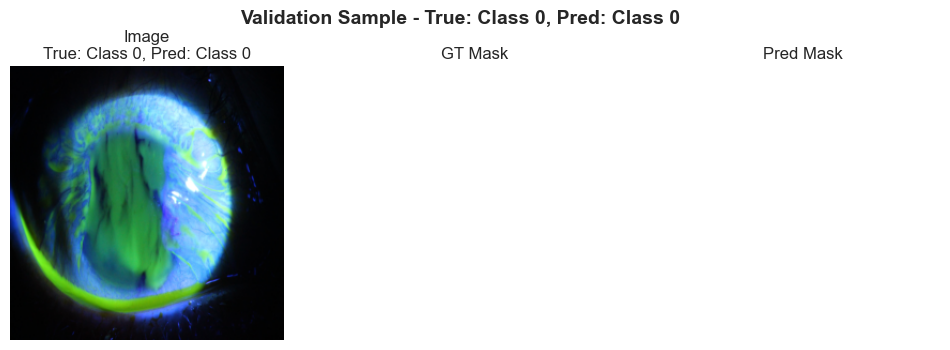

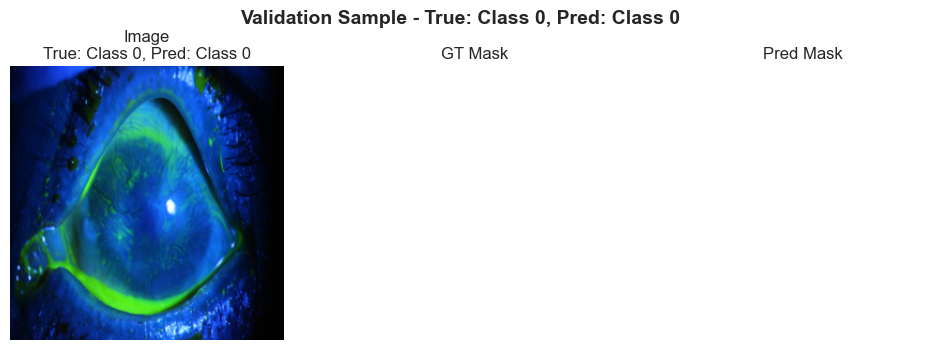

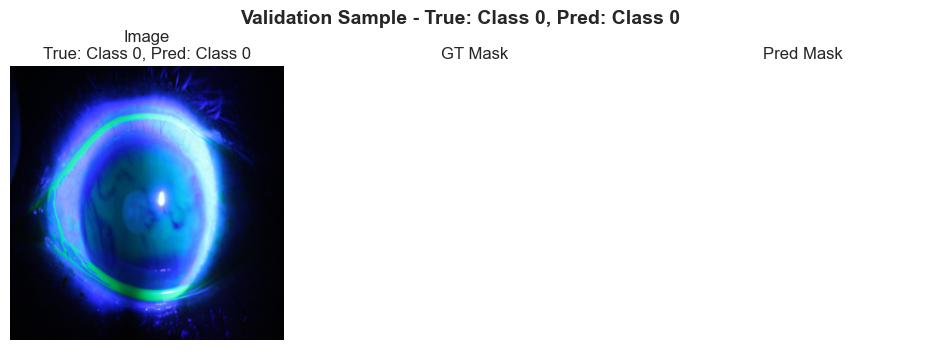

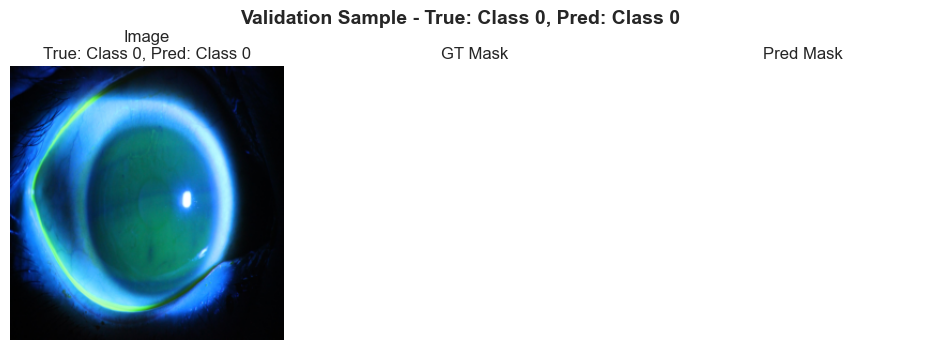

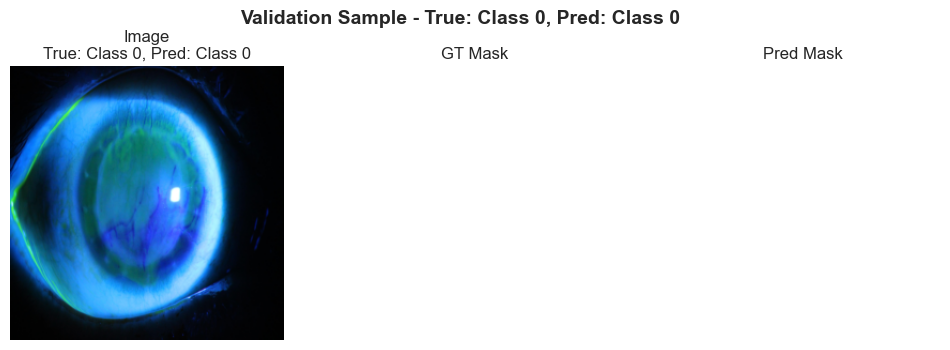

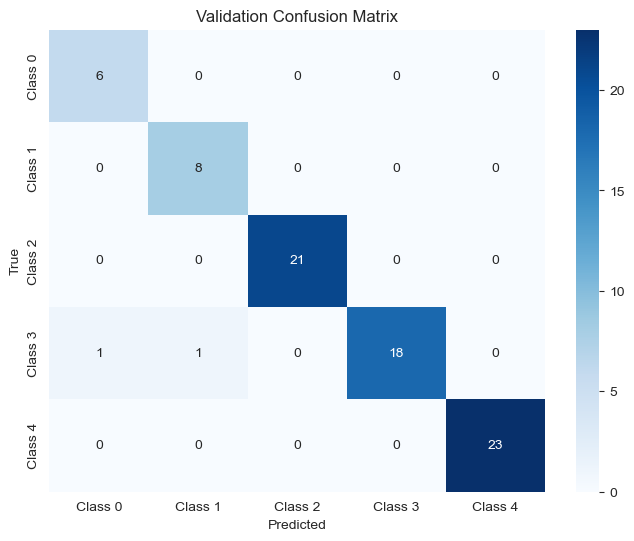

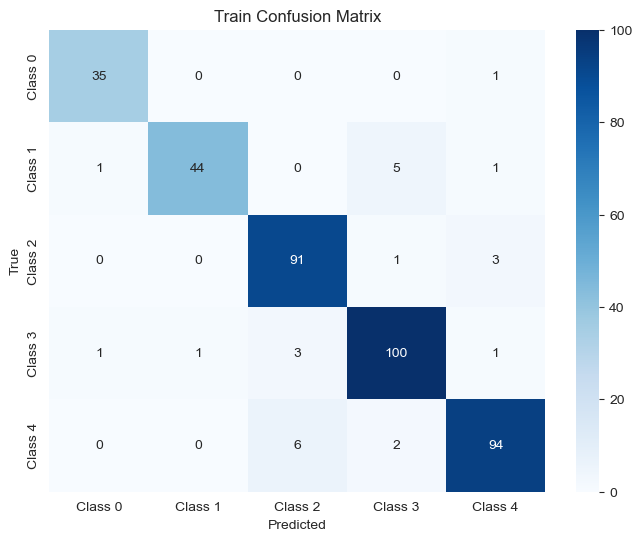

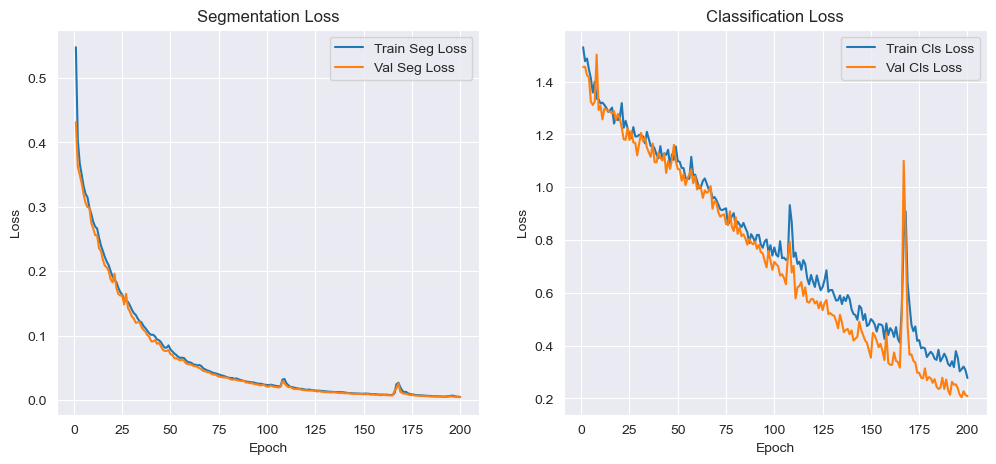

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = AttentionUNet(in_channels=3, out_channels=1).to(device)
classifier = ClassifierCNNMLP(in_channels=64, num_classes=5).to(device)

criterion_seg = nn.BCEWithLogitsLoss()
criterion_cls = nn.CrossEntropyLoss()

optimizer_unet = optim.Adam(unet.parameters(), lr=1e-4)
optimizer_classifier = optim.Adam(classifier.parameters(), lr=1e-4)

num_epochs = 200

train_losses_seg, val_losses_seg, train_losses_cls, val_losses_cls, val_preds_cls, val_labels_cls, train_preds_cls, train_labels_cls, val_preds_seg, val_labels_seg = train_loop(
    unet, classifier, device, train_loader, val_loader, 
    optimizer_unet, optimizer_classifier, criterion_seg, criterion_cls, num_epochs
)


class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]
plot_confusion_matrix(val_preds_cls, val_labels_cls, class_names=class_names, dataset_type="Validation")

plot_confusion_matrix(train_preds_cls, train_labels_cls, class_names=class_names, dataset_type="Train")

plot_losses(train_losses_seg, val_losses_seg, train_losses_cls, val_losses_cls)